# Ejercicio guiado: Perceptrón monocapa

> A partir de las diapositivas vistas en clase, debéis desarrollar e interpretar la implementación de un perceptrón monocapa para un problema de clasificación binaria lineal.
>
> Se parte del siguiente conjunto de datos:
> - X1 = [1, 0, 3, 5, 8, 3, 5]
> - X2 = [1, 2, 3, 7, 9, 8, 6]
> - D = [0, 0, 1, 1, 1, 1, 1]
>
> Donde:
> - cada par `(X1[i], X2[i])` representa un patrón de entrada,
> - `D` indica la clase real de cada patrón,
> - `0` significa que el punto no pertenece a la clase,
> - `1` significa que el punto sí pertenece a la clase.

> **Objetivo del ejercicio**
>
> Implementar el entrenamiento de un perceptrón monocapa siguiendo la misma lógica explicada en las diapositivas y desarrollada en el Colab trabajado en clase.

El código de clase está escrito en MATLAB/Octave (PerceptronSimple4.m). Lo que sigue es una traducción línea a línea a Python, manteniendo la misma lógica, los mismos nombres de variable y la misma estructura de bucles.

Librerías necesarias. `clear_output` hace el papel del `clc` de MATLAB. `time.sleep` equivale al `pause(1)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

> **Qué debéis hacer**
>
> 1. Definir los datos de entrada y la salida deseada.
> 2. Inicializar aleatoriamente los pesos `w1`, `w2` y el sesgo `b`.
> 3. Fijar una tasa de aprendizaje `alfa`.

`X1` y `X2` son los vectores de entrada. `D` contiene la clase real de cada patrón. Los pesos y el sesgo se inicializan con `rand()`, igual que en el código de clase. `alfa = 0.1` es la tasa de aprendizaje: controla cuánto se corrigen los pesos en cada paso.

In [2]:
# --- Datos de Entrada ---
X1 = np.array([1, 0, 3, 5, 8, 3, 5], dtype=float)
X2 = np.array([1, 2, 3, 7, 9, 8, 6], dtype=float)
D  = np.array([0, 0, 1, 1, 1, 1, 1], dtype=float)

# --- Inicialización ---
w1   = np.random.rand()
w2   = np.random.rand()
b    = np.random.rand()
alfa = 0.1

Y = np.zeros(len(X1))

> 4. Recorrer varias épocas de entrenamiento.
> 5. Calcular en cada época la salida lineal del perceptrón: `Z = w1·X1 + w2·X2 - b`

`Z` es la suma ponderada de las entradas menos el sesgo. Geometricamente, `Z = 0` es la recta que separa las dos clases. Los puntos con `Z > 0` quedan a un lado; los de `Z <= 0`, al otro.

> 6. Aplicar la función escalón para obtener la predicción `Y`.

Si `Z[q] > 0` la salida es `1` (pertenece a la clase). Si no, es `0`. Es la función de Heaviside: el perceptrón solo puede dar dos respuestas posibles.

> 7. Calcular el error de cada patrón.
> 8. Actualizar pesos y sesgo usando la regla de aprendizaje del perceptrón.

`error = D[i] - Y[i]` puede valer 0, 1 o -1.
- Si vale 0: la predicción es correcta, no se toca nada.
- Si vale 1: el perceptrón no se activó cuando debía, los pesos suben.
- Si vale -1: el perceptrón se activó cuando no debía, los pesos bajan.

El sesgo se actualiza con signo negativo porque aparece restado en `Z`.

> 9. Representar gráficamente la frontera de decisión.

La frontera es la recta donde `Z = 0`. Despejando `X2`:

```
w1·X1 + w2·X2 - b = 0  →  X2 = (-w1/w2)·X1 + b/w2
```

Esa es la función `f` que se dibuja en cada época. El título del eje en el código de clase la escribe como `-w1/w2 x + b/w2`.

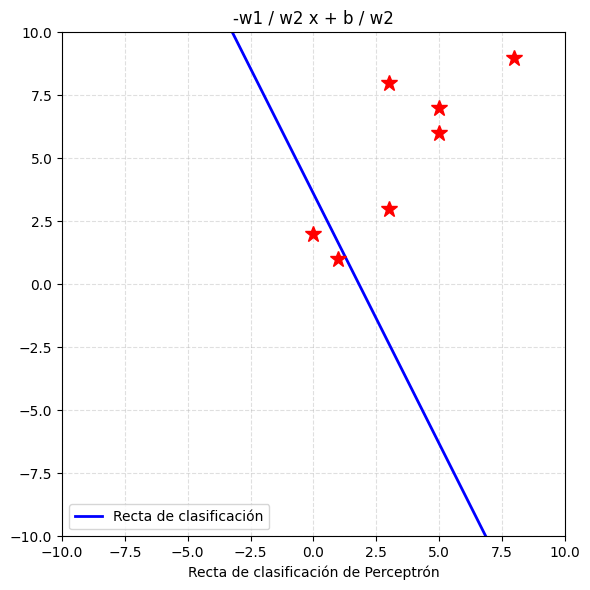

w1=0.4322  w2=0.2179  b=0.7859
E = [0. 0. 0. 0. 0. 0. 0.]


In [3]:
for epocas in range(1, 11):   # for epocas=1:10

    # --- Calculo del Perceptron ---
    Z = X1*w1 + X2*w2 - b

    for q in range(len(Z)):   # for q=1:length(Z)
        if Z[q] > 0:
            Y[q] = 1
        else:
            Y[q] = 0

    # --- Ajuste de Pesos ---
    for i in range(len(Z)):   # for i=1:length(Z)
        error  = D[i] - Y[i]
        b_inc  = -alfa * error
        w1_inc =  alfa * error * X1[i]
        w2_inc =  alfa * error * X2[i]
        b  = b  + b_inc
        w1 = w1 + w1_inc
        w2 = w2 + w2_inc

    # --- Dibuja los resultados parciales ---
    time.sleep(1)              # pause(1)

    x = np.linspace(-10, 10, 200)
    if abs(w2) > 1e-9:
        f = -w1/w2 * x + b/w2  # f=@(x) -w1/w2*x+b/w2
    else:
        f = np.full_like(x, np.nan)

    clear_output(wait=True)    # clc
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(x, f, 'b-', linewidth=1.5,
            label=f'-w1/w2·x + b/w2  (época {epocas})')
    ax.plot(X1, X2, '*r', markersize=10)   # plot(X1,X2,'*r')
    ax.axis([-10, 10, -10, 10])            # axis([-10 10 -10 10])
    ax.set_xlabel('x')
    ax.set_title(f'-w1 / w2 x + b / w2   (época {epocas})')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Comprobación del error ---
    Z = X1*w1 + X2*w2 - b

    for i in range(len(Z)):   # for i=1:length(Z)
        if Z[i] > 0:
            Y[i] = 1
        else:
            Y[i] = 0

    E = D - Y

    if abs(sum(E)) < 0.1:     # if abs(sum(E))<0.1
        print(f'Convergencia en época {epocas}')
        break

# --- Fin de epocas ---
clear_output(wait=True)       # clc

# --- Gráfica final ---
x = np.linspace(-10, 10, 200)
if abs(w2) > 1e-9:
    f = -w1/w2 * x + b/w2
else:
    f = np.full_like(x, np.nan)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, f, 'b-', linewidth=2, label='Recta de clasificación')
ax.plot(X1, X2, '*r', markersize=12)
ax.axis([-10, 10, -10, 10])
ax.set_xlabel('Recta de clasificación de Perceptrón')
ax.set_title('-w1 / w2 x + b / w2')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'w1={w1:.4f}  w2={w2:.4f}  b={b:.4f}')
print(f'E = {E}')

> 10. Comprobar al final si el modelo clasifica correctamente todos los patrones.

Se recalcula `Z` e `Y` con los pesos finales y se comprueba si `E = D - Y` es el vector cero. Si lo es, el perceptrón ha aprendido a separar las dos clases sin ningún error.

In [4]:
# --- Comprobación final ---
Z_final = X1*w1 + X2*w2 - b
Y_final = np.where(Z_final > 0, 1.0, 0.0)
E_final = D - Y_final

print(f'Vector de errores final: E = {E_final}')
if all(E_final == 0):
    print('Todos los patrones se clasifican correctamente.')
else:
    print(f'Patrones mal clasificados: {int(sum(abs(E_final)))}')

Vector de errores final: E = [0. 0. 0. 0. 0. 0. 0.]
Todos los patrones se clasifican correctamente.


> **¿Qué se valorará?**
>
> - Comprensión del cálculo de `Z`

*`Z = w1·X1 + w2·X2 - b` es la salida lineal del perceptrón. Cada entrada se multiplica por su peso correspondiente, se suman los productos y se resta el sesgo. El resultado es un número real cuyo signo decide la clase asignada.*

> - Interpretación de la salida `Y`

*`Y` es la predicción binaria. Si `Z > 0`, el punto cae por encima de la frontera y se asigna clase 1. Si `Z <= 0`, se asigna clase 0. No hay valor intermedio.*

> - Comprensión del ajuste de pesos y sesgo

*Los pesos se mueven en la dirección del error. Si el perceptrón falla, la magnitud del ajuste depende de `alfa` y del valor de la entrada en ese patrón. El sesgo se corrige con signo contrario al error porque aparece restado en `Z`.*

> - Interpretación del error `E = D - Y`

*`E` indica cuánto se equivoca el perceptrón en cada patrón. Solo puede valer 0 (acierto), 1 (debía dar 1 y dio 0) o -1 (debía dar 0 y dio 1). Cuando todos los valores de `E` son 0, el entrenamiento termina.*

> - Relación entre el código y la recta de clasificación obtenida

*La recta que se dibuja en cada época es `X2 = (-w1/w2)·X1 + b/w2`, que es exactamente donde `Z = 0`. Al ajustar los pesos, la recta gira y se desplaza hasta dejar los puntos de clase 0 a un lado y los de clase 1 al otro.*

> - Capacidad para explicar por qué el perceptrón converge en este ejemplo

*Los datos son linealmente separables: existe una recta que los divide sin ambigüedad. El teorema de convergencia del perceptrón garantiza que, en ese caso, el algoritmo llega a error cero en un número finito de épocas.*

> **Pregunta final de reflexión**
>
> Una vez ejecutado el Colab, explica con tus palabras por qué este problema puede resolverse con un perceptrón monocapa y qué ocurriría si los datos no fueran linealmente separables.

*Este problema se puede resolver con un perceptrón monocapa porque los datos son linealmente separables. Si se dibujan los siete puntos en el plano, existe al menos una recta que deja los dos puntos de clase 0 a un lado y los cinco de clase 1 al otro. El perceptrón solo puede aprender fronteras lineales, pero aquí eso es suficiente.*

*Si los datos no fueran linealmente separables, el algoritmo no convergería. Cada corrección que resuelve un patrón desclasifica otro, y el proceso no llega nunca a error cero. El caso más conocido es el XOR: cuatro puntos que ninguna recta separa correctamente. Para ese tipo de problemas hace falta una red con al menos una capa oculta, que puede aprender fronteras curvas o discontinuas.*